Graph Info에 중요한 정보가 모두 포함됨. 이를 지표삼아서 하면 됨  
기댓값은 exp_dict에 Trial number를 key로 하여 저장함

In [1]:
import sys
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

# 현재 디렉토리와 상위 디렉토리(Repo Root)를 경로에 추가하여 모듈 임포트
# 여기서 path를 적절히 고치면 됨
sys.path.append('/home/ubuntu/PPS-lab/test_qaoa')
from src_tensor.api import compile_expval_program
from make_qaoa_problem import _make_erdos_renyi_graph as make_erdos_renyi_graph
from qaoa_surrogate_common import (
    make_ring_chord_graph,
    build_qaoa_circuit,
    build_maxcut_observable,
    build_qaoa_theta_init_tqa,
    expected_cut_from_sum_zz,
    canonical_edge
)

In [2]:
# Configuration
N_QUBITS = 30
P_LAYERS = 5
DELTA_T = 0.8  # TQA initialization parameter
STEPS = 150
LR = 0.05
EDGE_PROB = 0.25
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Set seeds for reproducibility
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"Device: {DEVICE}")
print(f"Problem: N={N_QUBITS}, p={P_LAYERS}")

Device: cuda
Problem: N=30, p=5


In [3]:
def plot_graph_circle(n, edges):
    theta = np.linspace(0, 2*np.pi, n, endpoint=False)
    x = np.cos(theta)
    y = np.sin(theta)

    plt.figure(figsize=(6, 6))
    # Draw edges
    for u, v in edges:
        plt.plot([x[u], x[v]], [y[u], y[v]], color="gray", alpha=0.5)
    # Draw nodes
    plt.scatter(x, y, s=200, c='skyblue', edgecolors='black')
    for i in range(n):
        plt.text(x[i]*1.1, y[i]*1.1, str(i), ha='center', va='center')
    plt.axis('off')
    plt.title(f"Ring-Chord Graph (n={n})")
    # plt.show()

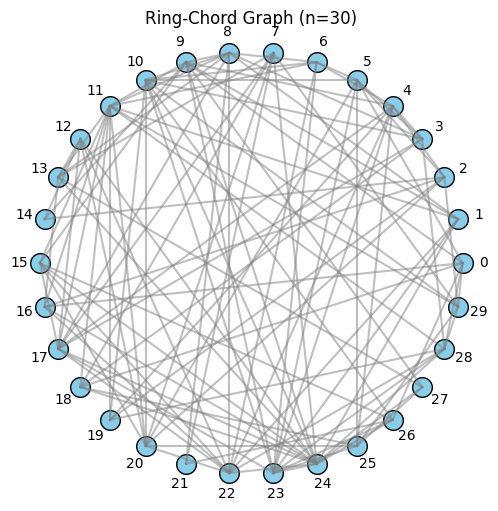

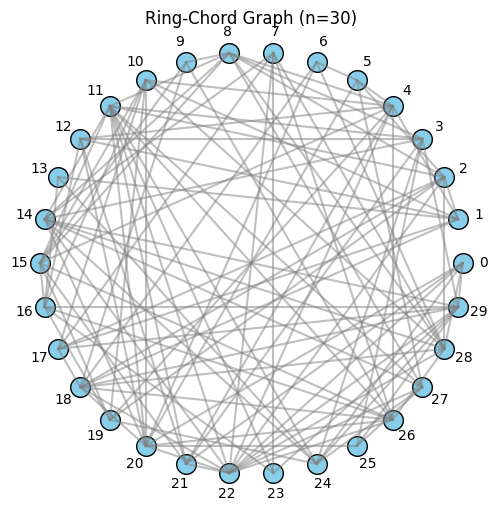

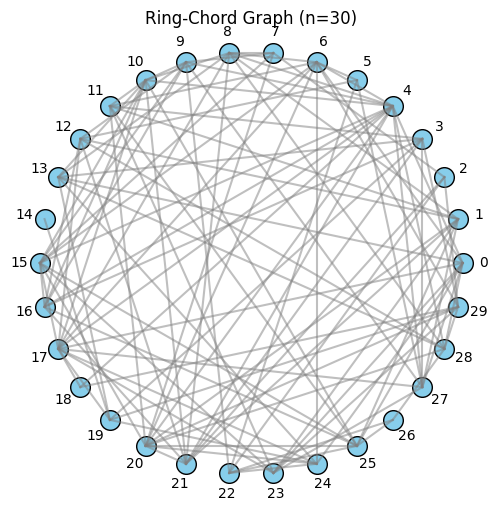

In [4]:
N_TRIAL = 3 # 적절히 조절할 것 원하는 만큼 레퍼런스 만드셈
graph_info = {
    f'Trial {i+1}': {} for i in range(N_TRIAL)
}

############# 그래프 및 회로 생성 ############
SEED = 42
for i in range(N_TRIAL):
    SEED += i*3
    edges = make_erdos_renyi_graph(n_qubits = N_QUBITS, edge_prob=0.25, seed=SEED,
                               ensure_connected=True, max_tries=3)
    n_edges = len(edges)
    
    plot_graph_circle(N_QUBITS, edges)

    graph_info[f"Trial {i+1}"]['edges'] = edges
    graph_info[f"Trial {i+1}"]['n_edges'] = n_edges


    circuit, n_params = build_qaoa_circuit(N_QUBITS, edges, P_LAYERS)
    zz_obj = build_maxcut_observable(N_QUBITS, edges)


    graph_info[f"Trial {i+1}"]['circuit'] = circuit    
    graph_info[f"Trial {i+1}"]['zz_obj'] = zz_obj
    graph_info[f"Trial {i+1}"]['n_params'] = n_params
# 키가 'circuit', 'zz_obj', 'thetas'이고 원소가 빈 사전

    init_theta_np = build_qaoa_theta_init_tqa(p_layers=P_LAYERS,
                                            n_qubits=N_QUBITS,
                                            delta_t=DELTA_T,
                                            n_edges = n_edges,
                                            dtype=np.float64)

    graph_info[f"Trial {i+1}"]['thetas'] = init_theta_np

In [6]:
print(graph_info['Trial 1'].keys())
graph_info

dict_keys(['edges', 'n_edges', 'circuit', 'zz_obj', 'n_params', 'thetas'])


{'Trial 1': {'edges': [(0, 5),
   (0, 9),
   (0, 16),
   (0, 18),
   (0, 26),
   (0, 28),
   (0, 29),
   (1, 8),
   (1, 9),
   (1, 11),
   (1, 22),
   (1, 23),
   (1, 24),
   (2, 4),
   (2, 5),
   (2, 14),
   (2, 16),
   (2, 19),
   (2, 20),
   (2, 29),
   (3, 4),
   (3, 5),
   (3, 8),
   (3, 10),
   (3, 17),
   (3, 18),
   (3, 28),
   (4, 6),
   (4, 9),
   (4, 17),
   (4, 19),
   (4, 22),
   (4, 23),
   (4, 25),
   (5, 6),
   (5, 10),
   (5, 20),
   (5, 23),
   (5, 25),
   (6, 8),
   (6, 10),
   (6, 11),
   (6, 22),
   (6, 23),
   (7, 13),
   (7, 17),
   (7, 18),
   (7, 20),
   (7, 21),
   (7, 24),
   (7, 29),
   (8, 9),
   (8, 10),
   (8, 11),
   (8, 13),
   (8, 17),
   (8, 21),
   (8, 22),
   (9, 11),
   (9, 14),
   (9, 15),
   (9, 23),
   (9, 24),
   (9, 27),
   (10, 19),
   (10, 20),
   (10, 23),
   (10, 24),
   (10, 26),
   (10, 29),
   (11, 13),
   (11, 15),
   (11, 16),
   (11, 17),
   (11, 18),
   (11, 19),
   (11, 20),
   (11, 28),
   (11, 29),
   (12, 13),
   (12, 14),
   (1

In [7]:
import cudaq
from cudaq import spin
from typing import List, Tuple, Optional

exp_dict = {f'Trial {i+1}': {} for i in range(N_TRIAL)}

for trial in range(N_TRIAL):
    
    thetas = graph_info[f"Trial {trial+1}"]['thetas']
    thetas = np.asarray(thetas, dtype=np.float64).reshape(-1)

    params_list = [float(x) for x in thetas.tolist()]

    edges = graph_info[f"Trial {trial+1}"]['edges']
    obs_list = []
    for i, j in edges:
        obs_list.append(spin.z(i)*spin.z(j))

    # 커널 정의
    kernel, params = cudaq.make_kernel(list[float])
    q = kernel.qalloc(int(N_QUBITS))

    # 초기 상태 |+>
    for i in range(int(N_QUBITS)):
        kernel.h(q[i])

    # QAOA 레이어 적용
    for layer in range(int(P_LAYERS)):
        gamma_idx = 2 * layer
        beta_idx = 2 * layer + 1
        for (u, v) in edges:
            uu = int(u)
            vv = int(v)
            # ZZ rotation: CNOT - RZ - CNOT
            kernel.cx(q[uu], q[vv])
            kernel.rz(params[gamma_idx], q[vv])
            kernel.cx(q[uu], q[vv])
        for i in range(int(N_QUBITS)):
            kernel.rx(params[beta_idx], q[i])

    exp_list = cudaq.observe(kernel, obs_list, params_list)
    exps =  [exp.expectation() for exp in exp_list]

    for idx, (i, j) in enumerate(edges):
        exp_dict[f'Trial {trial + 1}'][f"{i,j}"] = exps[idx]

In [8]:
# 얘는 첫번째 시도의 ZZ(i, j) 값을 키와 값으로 가짐
exp_dict['Trial 1']

{'(0, 5)': 0.2894765368433239,
 '(0, 9)': 0.2778908211689596,
 '(0, 16)': 0.32245431711979444,
 '(0, 18)': 0.35176828719995523,
 '(0, 26)': 0.318593916062988,
 '(0, 28)': 0.36640607244434586,
 '(0, 29)': 0.3844006518455775,
 '(1, 8)': 0.37691278619146484,
 '(1, 9)': 0.42309684281007587,
 '(1, 11)': 0.3242848549056022,
 '(1, 22)': 0.3362412936134466,
 '(1, 23)': 0.3263520687771069,
 '(1, 24)': 0.31681499125260987,
 '(2, 4)': 0.322685378503233,
 '(2, 5)': 0.34180539796970877,
 '(2, 14)': 0.38550499932648946,
 '(2, 16)': 0.29931199864514085,
 '(2, 19)': 0.40091563958088494,
 '(2, 20)': 0.35035056293619854,
 '(2, 29)': 0.33203637543864734,
 '(3, 4)': 0.33548688559077183,
 '(3, 5)': 0.3312681583271697,
 '(3, 8)': 0.3354044559429322,
 '(3, 10)': 0.3571321659365228,
 '(3, 17)': 0.334852549661004,
 '(3, 18)': 0.3187788316212471,
 '(3, 28)': 0.3095388271108934,
 '(4, 6)': 0.36003539056145245,
 '(4, 9)': 0.2884607973281089,
 '(4, 17)': 0.338066097501243,
 '(4, 19)': 0.3639491082278621,
 '(4, 22)